# Stochastic interpolant flow: VISp → VISrl (Allen Ca)

Following **Albergo et al.,** *Stochastic Interpolants with Data-Dependent Couplings* ([arXiv:2310.03725](https://arxiv.org/pdf/2310.03725)) with **paired** Allen Ca embeddings:

- **Algorithm 1 (training):** linear interpolant \(I_t = (1-t) x_0 + t x_1\) with \(x_0\) = standardized **VISp** and \(x_1\) = standardized **VISrl** (same trial index). Minimize \(\hat{\mathcal{L}}_b = \mathbb{E}[\|\hat b(I_t,t)\|^2 - 2\dot I_t \cdot \hat b(I_t,t)]\) with \(\dot I_t = x_1 - x_0\).
- **Algorithm 2 (sampling):** forward Euler \(X_{n+1} = X_n + \frac{1}{N}\hat b(X_n, n/N)\) starting from **VISp test** \(z\)-scores; the endpoint lies in **VISrl** \(z\)-space for decoding.

| File | Role |
|------|------|
| `signal_model.py` | `MLP_Residual`, `training_loss_algorithm1` / `cfm_loss_bridge`, `integrate_euler` (Algorithm 2), `frechet_embedding_distance` |
| (below) | MSE and embedding Fréchet (FID²) vs VISrl test in \(z\)-space |
| `signal_decode.py` | `allen_frame_id_decode` (`modality='ca'`) |
| Data | `../data/allen_data/VISp_*` and `VISrl_*` Ca train/test |

Decode in **VISrl** space: kNN train bank = VISrl train; test = VISrl test (**oracle**) vs flow from VISp test (**flow**).

## 1. Setup

In [7]:
import importlib.util
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def _find_signal_flow_dir() -> Path:
    """Works from signal_flow/, Flow_Hackathon/, or repo root (e.g. flow/)."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        for rel in (
            Path("signal_model.py"),
            Path("signal_flow") / "signal_model.py",
            Path("Flow_Hackathon") / "signal_flow" / "signal_model.py",
        ):
            p = d / rel
            if p.is_file():
                return p.parent
    raise FileNotFoundError(
        "Could not find signal_model.py. cd to Flow_Hackathon/signal_flow or open the notebook from that folder."
    )


def _load_module(name: str, path: Path):
    """Load from disk so edits + re-run work (avoids stale `signal_model` in sys.modules)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


FLOW_DIR = _find_signal_flow_dir()
if str(FLOW_DIR) not in sys.path:
    sys.path.insert(0, str(FLOW_DIR))

_sm = _load_module("signal_model", FLOW_DIR / "signal_model.py")
_sd = _load_module("signal_decode", FLOW_DIR / "signal_decode.py")

MLP_Residual = _sm.MLP_Residual
training_loss_algorithm1 = _sm.training_loss_algorithm1
cfm_loss_bridge = _sm.cfm_loss_bridge
integrate_euler = _sm.integrate_euler
frechet_embedding_distance = _sm.frechet_embedding_distance
allen_frame_id_decode = _sd.allen_frame_id_decode

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("signal_flow:", FLOW_DIR)

device: cuda:1
signal_flow: /home/fachengy/flow/Flow_Hackathon/signal_flow


## 2. Load Ca embeddings (train / test)

VISp / VISrl Ca `.npy` paths follow `Demo_Allen.ipynb` under `Flow_Hackathon/data/allen_data/` (paired trial order per seed).

In [8]:
DATA_DIR = (FLOW_DIR.parent / "data" / "allen_data").resolve()
seed = 333

paths = {
    "visp_train": DATA_DIR / f"VISp_joint_trained_ca_{seed}_train.npy",
    "visp_test": DATA_DIR / f"VISp_joint_trained_ca_{seed}_test.npy",
    "visrl_train": DATA_DIR / f"VISrl_joint_trained_ca_{seed}_train.npy",
    "visrl_test": DATA_DIR / f"VISrl_joint_trained_ca_{seed}_test.npy",
}
for k, p in paths.items():
    assert p.is_file(), f"Missing {k}: {p}"

visp_train = np.load(paths["visp_train"]).astype(np.float32)
visp_test = np.load(paths["visp_test"]).astype(np.float32)
visrl_train = np.load(paths["visrl_train"]).astype(np.float32)
visrl_test = np.load(paths["visrl_test"]).astype(np.float32)

assert visp_train.shape[0] == visrl_train.shape[0]
assert visp_test.shape[0] == visrl_test.shape[0]
assert visp_train.shape[1] == visrl_train.shape[1]

for name, a in [
    ("VISp train", visp_train),
    ("VISp test", visp_test),
    ("VISrl train", visrl_train),
    ("VISrl test", visrl_test),
]:
    print(f"{name}: shape {a.shape}")

VISp train: shape (8100, 128)
VISp test: shape (900, 128)
VISrl train: shape (8100, 128)
VISrl test: shape (900, 128)


## 3. Z-normalize VISp and VISrl (each fit on its own train)

**VISp** \(z\)-scores are \(x_0\) (flow start). **VISrl** \(z\)-scores are \(x_1\) (flow target and decode space). Each modality uses its own train mean/std.

In [9]:
eps = 1e-6


def standardize(x, mu, std):
    return (x - mu) / std


mu_visp, std_visp = visp_train.mean(0), visp_train.std(0) + eps
mu_visrl, std_visrl = visrl_train.mean(0), visrl_train.std(0) + eps

z_visp_tr = standardize(visp_train, mu_visp, std_visp)
z_visp_te = standardize(visp_test, mu_visp, std_visp)
z_visrl_tr = standardize(visrl_train, mu_visrl, std_visrl)
z_visrl_te = standardize(visrl_test, mu_visrl, std_visrl)

z_visp_tr_t = torch.from_numpy(z_visp_tr).to(device)
z_visp_te_t = torch.from_numpy(z_visp_te).to(device)
z_visrl_tr_t = torch.from_numpy(z_visrl_tr).to(device)
z_visrl_te_t = torch.from_numpy(z_visrl_te).to(device)

dim = z_visp_tr.shape[1]
print("dim:", dim, "| paired train:", z_visp_tr_t.shape, z_visrl_tr_t.shape)

dim: 128 | paired train: torch.Size([8100, 128]) torch.Size([8100, 128])


## 4. Train `MLP_Residual` (Algorithm 1, VISp → VISrl)

Minibatch paired \((x_0, x_1)\): **VISp train** \(z\) and **VISrl train** \(z\) at the same indices. `cfm_loss_bridge` is an alias for `training_loss_algorithm1` and implements **Algorithm 1** for the linear stochastic interpolant (Eq. (7) in the paper).

step     0  loss 20.229969
step   500  loss -256.886688
step  1000  loss -259.174530
step  1500  loss -257.799133
step  2000  loss -259.882690
step  2500  loss -259.027252
step  2999  loss -259.247253


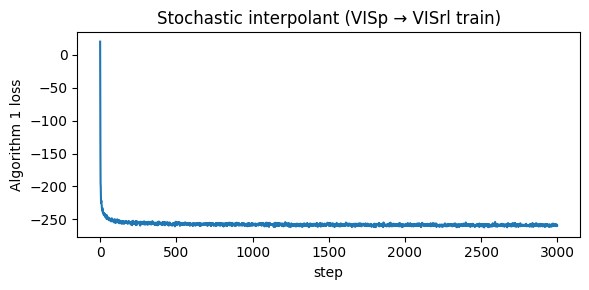

In [10]:
model = MLP_Residual(
    input_size=dim,
    hidden_size=512,
    amount_layers=5,
    output_size=dim,
    time_dimension=128,
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

BATCH = 512
STEPS = 3000
n_pair = z_visp_tr_t.shape[0]
assert n_pair == z_visrl_tr_t.shape[0]

losses = []
model.train()
for step in range(STEPS):
    idx = torch.randint(0, n_pair, (BATCH,), device=device)
    x0_b = z_visp_tr_t[idx]
    x1_b = z_visrl_tr_t[idx]
    loss = cfm_loss_bridge(model, x0_b, x1_b)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 500 == 0 or step == STEPS - 1:
        print(f"step {step:5d}  loss {loss.item():.6f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("Algorithm 1 loss")
plt.title("Stochastic interpolant (VISp → VISrl train)")
plt.tight_layout()
plt.show()

## 5. Integrate VISp test → VISrl z-space (**Algorithm 2**)

Forward Euler `integrate_euler` matches **Algorithm 2**: start from **standardized VISp test** embeddings (one trajectory per test trial). The end state lies in **VISrl** \(z\)-space for kNN decoding.

In [11]:
n_te = z_visp_te_t.shape[0]
assert n_te == z_visrl_te_t.shape[0]

with torch.no_grad():
    x_hat = integrate_euler(model, z_visp_te_t, n_steps=100)

z_flow_test = x_hat.cpu().numpy()
print("Flow output shape (VISrl z-space):", z_flow_test.shape)

Flow output shape (VISrl z-space): (900, 128)


## 6. Frame-ID decoding (`modality='ca'`)

Embeddings live in **VISrl** \(z\)-space. The next cell compares two **test** feature matrices against the same **train** bank (`z_visrl_tr`):

- **Oracle:** `z_visrl_te` — real held-out VISrl trials.
- **Flow:** `z_flow_test` — Euler endpoint starting from **VISp test** \(z\)-scores through the learned field (mapped into VISrl space).

Labels are frame indices **`0 … 899`** repeated over **9** train sessions (`8100` train rows) and **`900`** test trials (`900` test rows): “which frame of the movie does this trial look like?”

### How kNN accuracy is computed (`signal_decode.allen_frame_id_decode`)

1. **Classifier:** `sklearn.neighbors.KNeighborsClassifier` with **cosine** distance (the usual pipeline for these Allen embeddings).
2. **Choosing \(k\):** a small grid of candidate `n_neighbors` is tried. For each \(k\), the **train** set is split **8/9 vs 1/9** (by row order); the first chunk fits the kNN, predictions are made on the held-out chunk, and the \(k\) with lowest L1 frame error on that holdout is selected.
3. **Test:** a kNN with the chosen \(k\) is **refit on all train** rows, then predicts **test** frame labels from **test** embeddings.
4. **Reported accuracy (%)** is a **tolerant** match: a trial counts as correct if the absolute frame error is **\< 30** frames (`time_window=1` in code → threshold `30` frames). So this is “coarse frame ID” accuracy, not exact integer frame.

### 6b. Validation metrics vs VISrl test (later cell)

- **MSE:** mean squared error between **flow** endpoints and **VISrl test** embeddings (same trial pairing and \(z\)-scoring as decoding).
- **Embedding Fréchet distance (FID²):** `frechet_embedding_distance(z_visrl_te, z_flow_test)` — multivariate Gaussians fit to the two test batches in 128-D; lower is better. (Classical FID uses Inception features; here the Ca embeddings play that role.)

In [12]:
train_labels = np.tile(np.arange(900), 9)
test_labels = np.arange(900)
assert len(train_labels) == z_visrl_tr.shape[0]
assert len(test_labels) == z_visrl_te.shape[0]

_, _, acc_oracle = allen_frame_id_decode(
    z_visrl_tr,
    train_labels,
    z_visrl_te,
    test_labels,
    modality="ca",
    decoder="knn",
)

_, _, acc_flow = allen_frame_id_decode(
    z_visrl_tr,
    train_labels,
    z_flow_test,
    test_labels,
    modality="ca",
    decoder="knn",
)

print(f"Oracle  VISrl train → VISrl test:             {acc_oracle:.2f}%")
print(f"Flow    VISp test→Euler→VISrl bank decode:   {acc_flow:.2f}%")

Oracle  VISrl train → VISrl test:             11.67%
Flow    VISp test→Euler→VISrl bank decode:   39.22%


In [13]:
# MSE in VISrl z-space: flow endpoint vs held-out VISrl test (same trial pairing)
assert z_flow_test.shape == z_visrl_te.shape
diff = z_flow_test - z_visrl_te
mse = float(np.mean(diff ** 2))
rmse_elem = float(np.sqrt(mse))
per_trial_mse = np.mean(diff ** 2, axis=1)

print(f"MSE (mean over trials × dims):     {mse:.6f}")
print(f"RMSE (√MSE over all entries):        {rmse_elem:.6f}")
print(f"per-trial MSE — mean: {float(per_trial_mse.mean()):.6f},  median: {float(np.median(per_trial_mse)):.6f}")

fd2 = frechet_embedding_distance(z_visrl_te, z_flow_test)
print(f"Embedding Fréchet d² (FID²):       {fd2:.6f}")
print(f"Embedding Fréchet d (√FID²):       {np.sqrt(fd2):.6f}")

MSE (mean over trials × dims):     1.731581
RMSE (√MSE over all entries):        1.315896
per-trial MSE — mean: 1.731581,  median: 1.806809
Embedding Fréchet d² (FID²):       19.918312
Embedding Fréchet d (√FID²):       4.462994


## 7. Optional: 2D PCA glimpse

Subsampled **VISrl train**, **VISrl test** (oracle), and **flow** endpoints (VISp test → Euler) in one shared linear view.

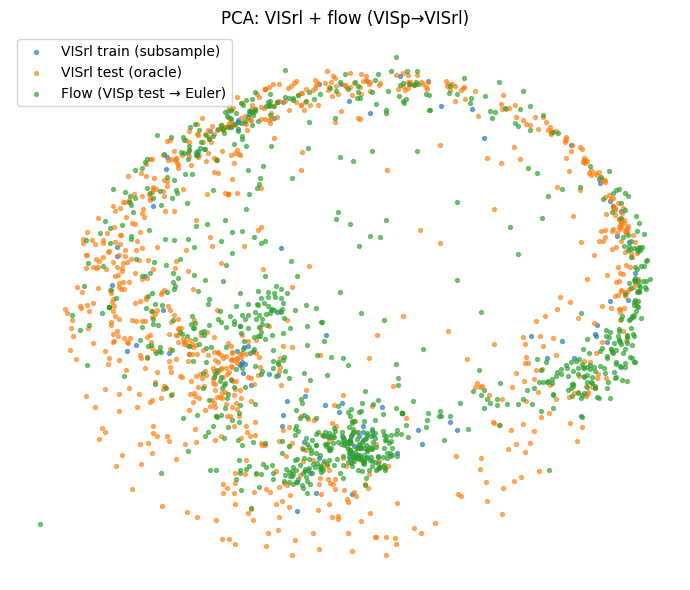

In [14]:
from sklearn.decomposition import PCA

Z = np.vstack([z_visrl_tr[::80], z_visrl_te, z_flow_test])
pca = PCA(n_components=2, random_state=0).fit(Z)


def proj(A):
    return pca.transform(A)


plt.figure(figsize=(7, 6))
plt.scatter(*proj(z_visrl_tr[::80]).T, s=8, alpha=0.6, label="VISrl train (subsample)")
plt.scatter(*proj(z_visrl_te).T, s=8, alpha=0.6, label="VISrl test (oracle)")
plt.scatter(*proj(z_flow_test).T, s=8, alpha=0.6, label="Flow (VISp test → Euler)")
plt.legend()
plt.title("PCA: VISrl + flow (VISp→VISrl)")
plt.axis("off")
plt.tight_layout()
plt.show()